In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import mlflow
import mlflow.sklearn
import pickle

In [2]:
df = pd.read_csv("../../data/crime_500k_cleaned.csv")
df.columns

Index(['Primary Type', 'Arrest', 'Domestic', 'District', 'Community Area',
       'Year', 'Latitude', 'Longitude', 'Hour', 'Day', 'Day_of_Week', 'Month',
       'Is_Weekend', 'Crime_Severity_Score', 'Season'],
      dtype='object')

In [3]:
print(df.shape)
print(df.dtypes.unique())

(480122, 15)
[dtype('O') dtype('int64') dtype('float64')]


In [4]:
cat_columns = df.select_dtypes(include="object").columns
num_columns = df.select_dtypes(include=["int64","float64"]).columns
print(cat_columns)
print(num_columns)

Index(['Primary Type', 'Season'], dtype='object')
Index(['Arrest', 'Domestic', 'District', 'Community Area', 'Year', 'Latitude',
       'Longitude', 'Hour', 'Day', 'Day_of_Week', 'Month', 'Is_Weekend',
       'Crime_Severity_Score'],
      dtype='object')


In [5]:
label_encoder = LabelEncoder()
df["Primary Type"] = label_encoder.fit_transform(df["Primary Type"])
df["Season"] = label_encoder.fit_transform(df["Season"])

In [23]:
X = df[["Latitude", "Longitude"]]

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
X_scaled[0]

array([ 0.58777863, -0.86973264])

In [26]:
wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print(wcss)

[437747.7863900494, 303384.8127036872, 225940.10099880653, 182551.67500476155, 145459.54800425647, 123133.04929157284, 108495.42649260306, 94829.25578657571, 84925.02500953941]


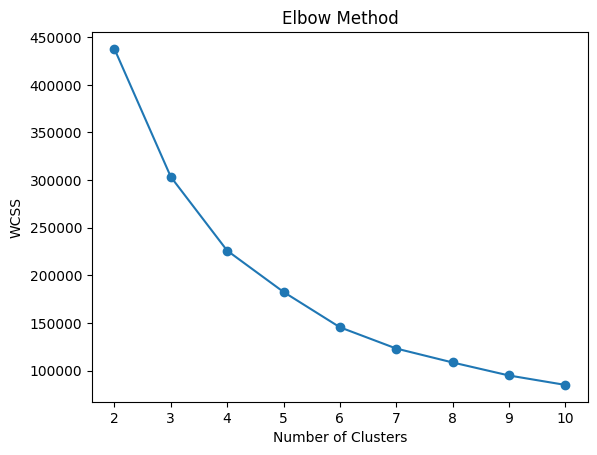

In [27]:
plt.plot(range(2,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [32]:
cluster = 5
kmeans = KMeans(n_clusters=cluster, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)

In [33]:
labels

array([4, 4, 1, ..., 2, 0, 4], shape=(480122,), dtype=int32)

In [34]:
centers = kmeans.cluster_centers_
centers

array([[-0.94007854, -0.08161361],
       [ 1.38520745, -0.10887303],
       [-1.13773873,  1.26909479],
       [ 0.33636704,  0.45692226],
       [ 0.61553009, -1.21722272]])

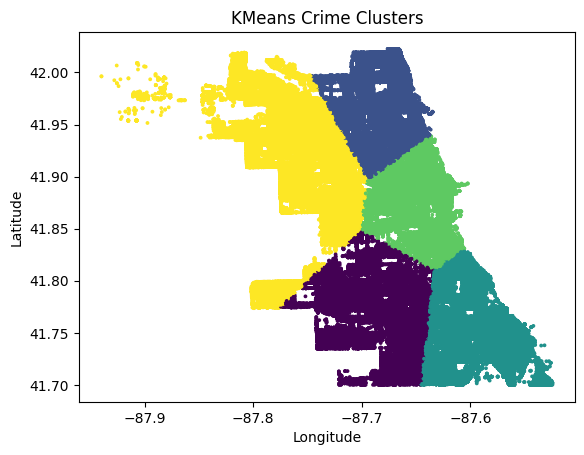

In [35]:
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=labels,
    cmap="viridis",
    s=3
)
plt.title("KMeans Crime Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [36]:
score = silhouette_score(X_scaled, labels)
print("KMeans Silhouette Score:", score)

KMeans Silhouette Score: 0.40871967129339


In [37]:
score = davies_bouldin_score(X_scaled, labels)
print(score)

0.810039000801865


In [38]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Clustering")
with mlflow.start_run(run_name="KMeans"):
    mlflow.log_param("clusters", cluster)
    mlflow.log_metric("silhouette_score", score)
    mlflow.sklearn.log_model(kmeans, "KMeans")

2026/03/11 17:00:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 17:00:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run KMeans at: http://127.0.0.1:5000/#/experiments/2/runs/133f0dab7de74e77a46e83091e72bdc6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [39]:
with open("../../models/kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

In [40]:
pickle.dump(scaler, open("../../models/scaler.pkl", "wb"))